# 04 — A/B Experiment Analysis & CLV Modeling

This notebook covers the two quantitative analyses at the core of the project.
The first half treats free-shipping orders as a natural experiment and rigorously
tests whether free shipping changes revenue, item count, and review scores —
running a power analysis, balance check, t-test, Mann-Whitney robustness check,
and a regression-adjusted estimate. The second half models customer lifetime value
both historically and probabilistically using the BG/NBD + Gamma-Gamma framework,
then cross-validates CLV tiers against RFM segments.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..').resolve()))

from src.data_processing import load_processed
from src.ab_testing import (
    construct_experiment,
    check_balance,
    run_ttest,
    run_mann_whitney,
    regression_adjusted_ate,
    compute_sample_size,
    plot_ab_distributions,
    plot_confidence_intervals,
)
from src.clv_model import (
    compute_historical_clv,
    compute_probabilistic_clv,
    plot_clv_distribution,
    plot_clv_by_category,
)
from src.segmentation import compute_rfm, SEGMENT_COLORS

PROC_PATH = Path('../data/processed/orders_master.parquet')
RAW_DIR   = Path('../data/raw')
FIG_DIR   = Path('../outputs/figures')
TBL_DIR   = Path('../outputs/tables')

pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 40)

df = load_processed(PROC_PATH)
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Raw items needed to derive freight flags for the experiment
items_df = pd.read_csv(RAW_DIR / 'olist_order_items_dataset.csv')

print(f'Orders : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Items  : {items_df.shape[0]:,} rows')
print(f'Columns: {df.columns.tolist()}')

Orders : 96,477 rows x 18 cols
Items  : 112,650 rows
Columns: ['order_id', 'customer_unique_id', 'customer_state', 'seller_state', 'order_purchase_timestamp', 'order_month', 'cohort_month', 'cohort_index', 'order_year', 'order_dow', 'order_hour', 'delivery_days', 'revenue', 'payment_installments', 'item_count', 'avg_item_price', 'review_score', 'product_category']


## 1. Power Analysis

Before looking at any results we check whether the sample is large enough to
detect a meaningful effect. We frame this around Cohen's d — the lift in
revenue expressed in units of standard deviations. We compute the minimum
required sample size for several conventional effect sizes and compare against
what we actually have. We also show the minimum detectable effect (MDE) in
absolute revenue terms so the result is interpretable to a non-technical audience.

In [2]:
rev_mean = df['revenue'].mean()
rev_std  = df['revenue'].std()

power_rows = []
for d in [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]:
    ss = compute_sample_size(effect_size=d, alpha=0.05, power=0.80)
    mde_brl = d * rev_std
    mde_pct = mde_brl / rev_mean * 100
    power_rows.append({
        'cohens_d':      d,
        'mde_brl':       round(mde_brl, 2),
        'mde_pct':       round(mde_pct, 1),
        'n_per_group':   ss['n_per_group'],
        'total_n':       ss['total_n'],
    })

power_table = pd.DataFrame(power_rows)
power_table.to_csv(TBL_DIR / '04_power_analysis.csv', index=False)
print(f'Revenue mean : R${rev_mean:,.2f}   std : R${rev_std:,.2f}')
print(f'Saved → {TBL_DIR / "04_power_analysis.csv"}\n')
power_table

Revenue mean : R$159.86   std : R$218.81
Saved → ../outputs/tables/04_power_analysis.csv



,cohens_d,mde_brl,mde_pct,n_per_group,total_n
0,0.0500,10.9400,6.8000,6281,12562
1,0.1000,21.8800,13.7000,1571,3142
2,0.1500,32.8200,20.5000,699,1398
3,0.2000,43.7600,27.4000,394,788
4,0.3000,65.6400,41.1000,176,352
5,0.5000,109.4100,68.4000,64,128


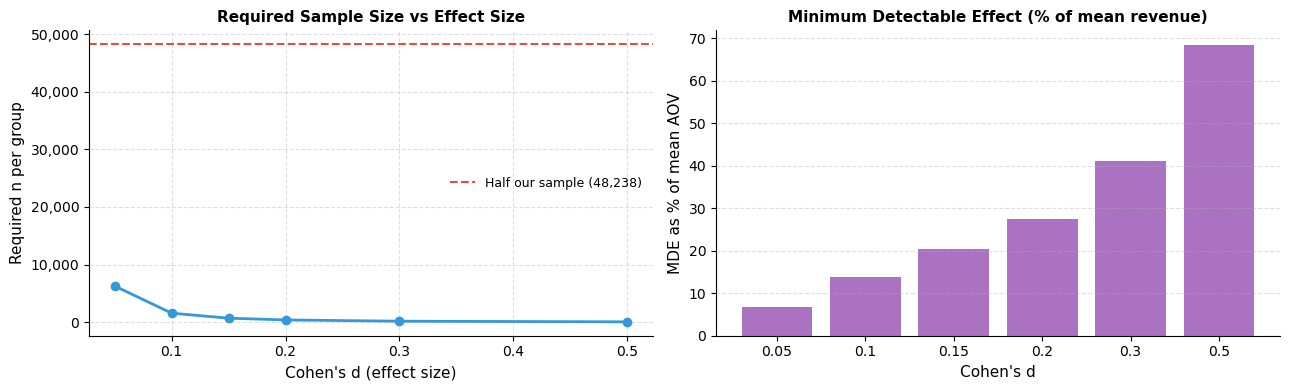

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(power_table['cohens_d'], power_table['n_per_group'],
         marker='o', color='#3498db', linewidth=2)
ax1.axhline(df.shape[0] // 2, color='#e74c3c', linestyle='--',
            label=f'Half our sample ({df.shape[0]//2:,})')
ax1.set_xlabel("Cohen's d (effect size)", fontsize=11)
ax1.set_ylabel('Required n per group', fontsize=11)
ax1.set_title('Required Sample Size vs Effect Size', fontsize=11, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax1.legend(frameon=False, fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

ax2.bar(power_table['cohens_d'].astype(str), power_table['mde_pct'],
        color='#9b59b6', edgecolor='none', alpha=0.85)
ax2.set_xlabel("Cohen's d", fontsize=11)
ax2.set_ylabel('MDE as % of mean AOV', fontsize=11)
ax2.set_title('Minimum Detectable Effect (% of mean revenue)', fontsize=11, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / '04_power_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Balance Check

We define the treatment group as orders where total freight value was zero
(free shipping) and the control group as orders with paid freight. Before
running any tests we check whether the two groups are comparable on observable
characteristics. The standardized mean difference (SMD) measures how far apart
the groups are on each covariate in units of standard deviations. An SMD above
0.1 in absolute value is the conventional flag for meaningful imbalance.

In [4]:
experiment_df = construct_experiment(df, items_df)

n_ctrl = (experiment_df['treatment'] == 0).sum()
n_trt  = (experiment_df['treatment'] == 1).sum()
print(f'Control   (paid freight) : {n_ctrl:,} orders  ({n_ctrl/len(experiment_df)*100:.1f}%)')
print(f'Treatment (free freight) : {n_trt:,} orders  ({n_trt/len(experiment_df)*100:.1f}%)')

Control   (paid freight) : 96,141 orders  (99.7%)
Treatment (free freight) : 336 orders  (0.3%)


In [5]:
balance = check_balance(experiment_df)
balance.to_csv(TBL_DIR / '04_balance_check.csv', index=False)
print(f'Saved → {TBL_DIR / "04_balance_check.csv"}')
balance

Saved → ../outputs/tables/04_balance_check.csv


,covariate,mean_control,mean_treatment,smd,balanced
0,avg_item_price,125.3155,102.1630,-0.1662,False
1,delivery_days,12.0901,12.9613,0.1070,False
2,payment_installments,2.9285,2.8006,-0.0504,True
3,item_count,1.1422,1.1310,-0.0231,True
4,cohort_index,0.0941,0.0982,0.0047,True


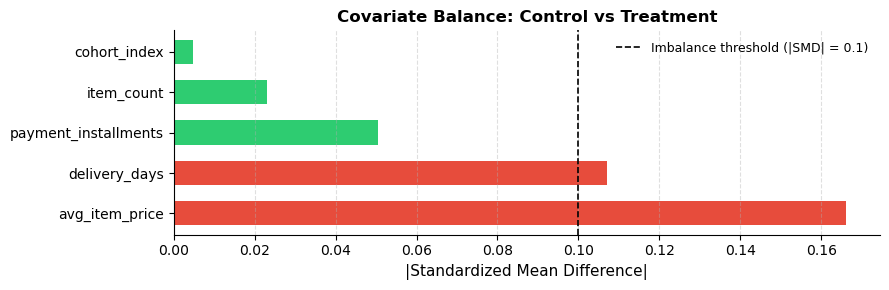

In [6]:
fig, ax = plt.subplots(figsize=(9, max(3, len(balance) * 0.55)))
colors = ['#e74c3c' if not b else '#2ecc71' for b in balance['balanced']]
bars = ax.barh(balance['covariate'], balance['smd'].abs(),
               color=colors, edgecolor='none', height=0.6)
ax.axvline(0.1, color='black', linestyle='--', linewidth=1.2,
           label='Imbalance threshold (|SMD| = 0.1)')
ax.set_xlabel('|Standardized Mean Difference|', fontsize=11)
ax.set_title('Covariate Balance: Control vs Treatment', fontsize=12, fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_balance_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. A/B Test Distributions

Before running formal tests we visually inspect the outcome distributions for
both groups. Revenue distributions in e-commerce are almost always right-skewed
so we show them on a log scale. If the two KDE curves are clearly separated the
effect is large; if they nearly overlap the effect is small regardless of the
p-value. We also look at item count and review score as secondary outcomes.

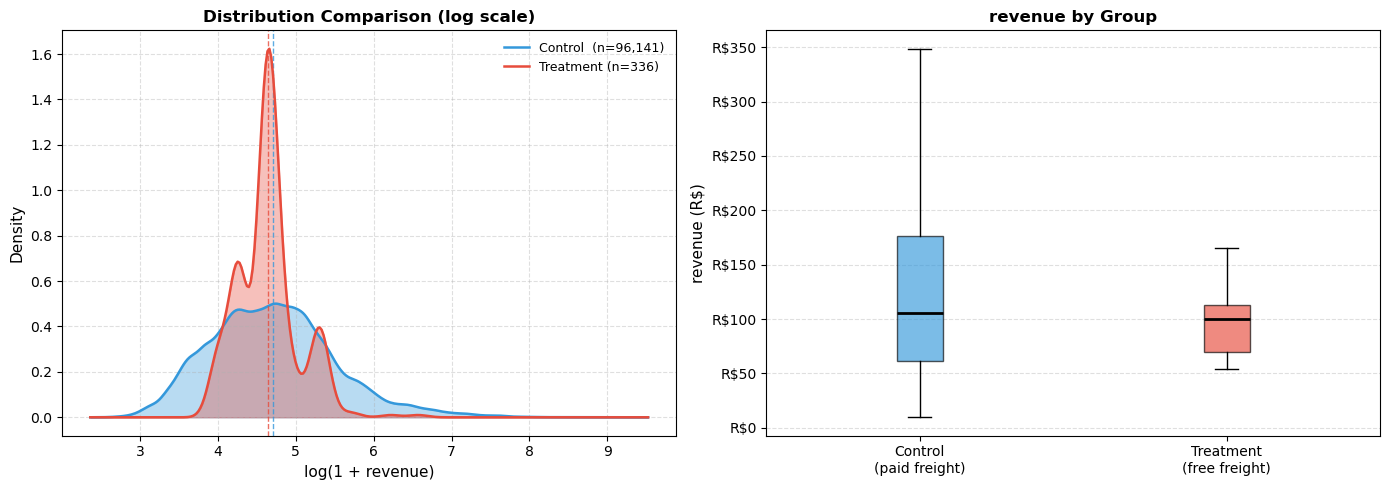

In [7]:
plot_ab_distributions(experiment_df, outcome_col='revenue',
                      path=FIG_DIR / '04_ab_dist_revenue.png')

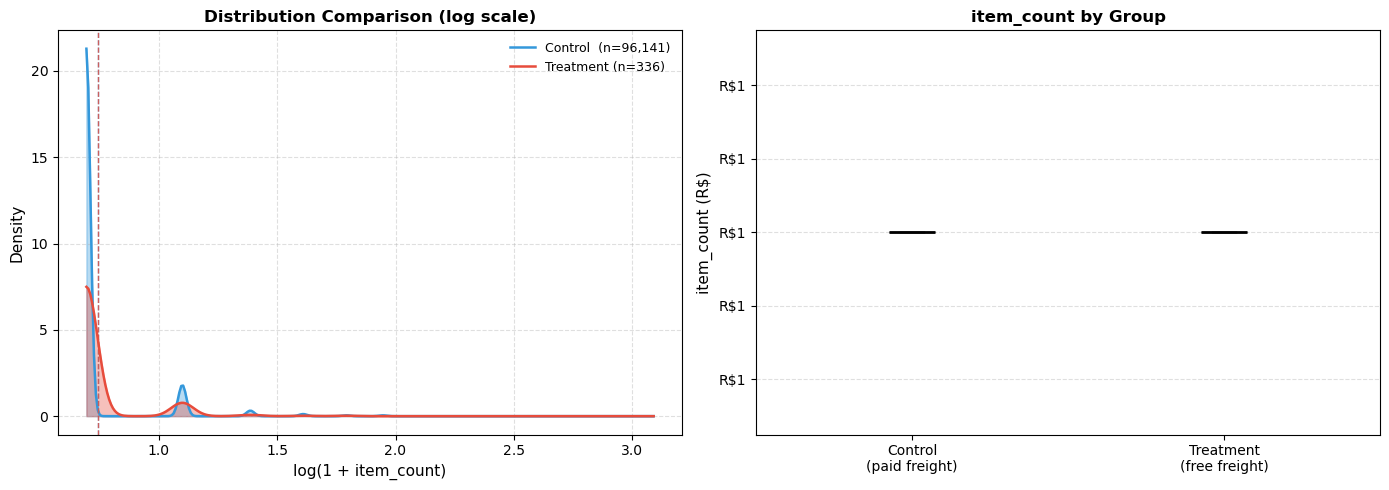

In [8]:
plot_ab_distributions(experiment_df, outcome_col='item_count',
                      path=FIG_DIR / '04_ab_dist_item_count.png')

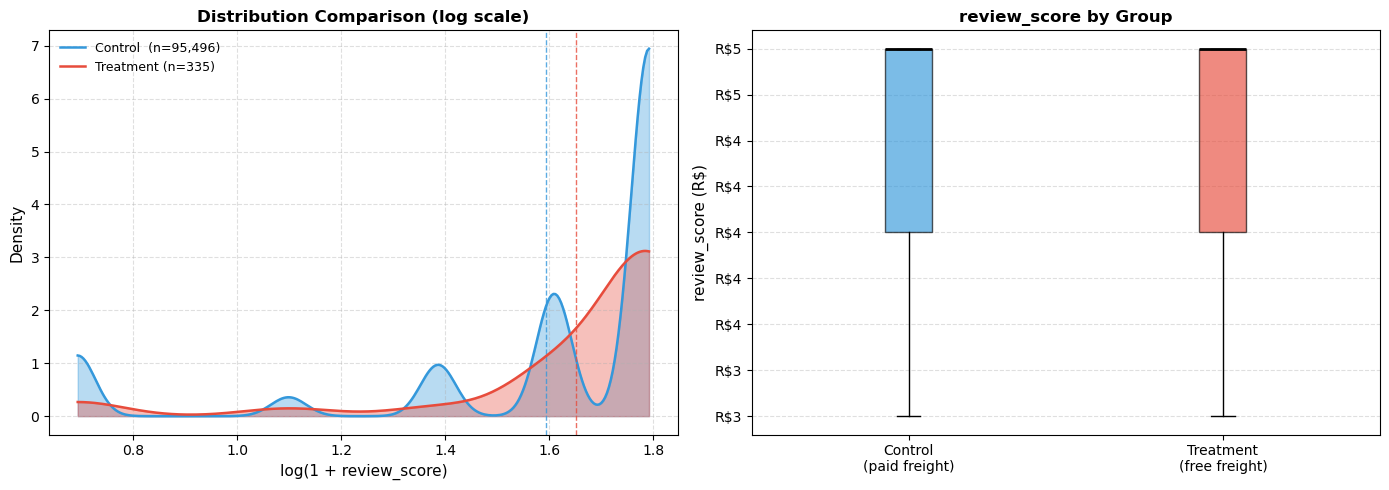

In [9]:
plot_ab_distributions(experiment_df, outcome_col='review_score',
                      path=FIG_DIR / '04_ab_dist_review_score.png')

## 4. T-test and Mann-Whitney Results

We run a Welch t-test (which does not assume equal variances) as the primary
inferential test, and a Mann-Whitney U test as a non-parametric robustness
check. If both tests agree on direction and significance we can be more
confident the result is not an artefact of distributional assumptions.
We report lift in absolute and percentage terms, Cohen's d for effect size,
and 95% confidence intervals — not just the p-value.

In [10]:
ttest_revenue = run_ttest(experiment_df, outcome_col='revenue')
ttest_items   = run_ttest(experiment_df, outcome_col='item_count')
ttest_review  = run_ttest(experiment_df, outcome_col='review_score')

ttest_results = pd.DataFrame([ttest_revenue, ttest_items, ttest_review])
display_cols  = ['outcome', 'mean_control', 'mean_treatment', 'estimate',
                 'lift_pct', 'cohens_d', 'ci_lower', 'ci_upper', 'p_value']
print('=== Welch T-test Results ===')
ttest_results[display_cols].round(4)

=== Welch T-test Results ===


,outcome,mean_control,mean_treatment,estimate,lift_pct,cohens_d,ci_lower,ci_upper,p_value
0,revenue,160.0247,111.7011,-48.3236,-30.1980,-0.3013,-54.7611,-41.8860,0.0000
1,item_count,1.1422,1.1310,-0.0113,-0.9860,-0.0231,-0.0576,0.0351,0.6331
2,review_score,4.1551,4.3881,0.2329,5.6060,0.1940,0.1134,0.3525,0.0002


In [11]:
mw_revenue = run_mann_whitney(experiment_df, outcome_col='revenue')
mw_items   = run_mann_whitney(experiment_df, outcome_col='item_count')
mw_review  = run_mann_whitney(experiment_df, outcome_col='review_score')

mw_results = pd.DataFrame([mw_revenue, mw_items, mw_review])
mw_display = ['outcome', 'median_control', 'median_treatment',
              'rank_biserial_r', 'p_value', 'n_control', 'n_treatment']
print('=== Mann-Whitney U Results ===')
mw_results[mw_display].round(4)

=== Mann-Whitney U Results ===


,outcome,median_control,median_treatment,rank_biserial_r,p_value,n_control,n_treatment
0,revenue,105.2800,99.9000,0.0271,0.3897,96141,336
1,item_count,1.0000,1.0000,-0.0063,0.7013,96141,336
2,review_score,5.0000,5.0000,-0.0941,0.0008,95496,335


In [12]:
# Save both test result tables
ttest_results.to_csv(TBL_DIR / '04_ttest_results.csv', index=False)
mw_results.to_csv(TBL_DIR   / '04_mann_whitney_results.csv', index=False)
print(f'Saved → {TBL_DIR / "04_ttest_results.csv"}')
print(f'Saved → {TBL_DIR / "04_mann_whitney_results.csv"}')

Saved → ../outputs/tables/04_ttest_results.csv
Saved → ../outputs/tables/04_mann_whitney_results.csv


## 5. Regression-Adjusted ATE

The t-test gives the raw difference in means. If the two groups differ on
observable characteristics — which the balance check above reveals — that
difference may partly reflect confounders rather than the free-shipping
treatment. OLS regression lets us partial out the effect of covariates
(item count, price, delivery days, etc.) to get a cleaner estimate of the
average treatment effect. We use HC3 robust standard errors to guard against
heteroskedasticity, which is almost guaranteed with skewed revenue data.

In [13]:
reg_revenue = regression_adjusted_ate(experiment_df, outcome_col='revenue')
reg_items   = regression_adjusted_ate(experiment_df, outcome_col='item_count')
reg_review  = regression_adjusted_ate(experiment_df, outcome_col='review_score')

reg_results = pd.DataFrame([reg_revenue, reg_items, reg_review])
reg_display = ['outcome', 'estimate', 'se', 'ci_lower', 'ci_upper', 'p_value', 'r_squared', 'n_obs']
print('=== OLS Regression-Adjusted ATE (HC3) ===')
reg_results[reg_display].round(4)

=== OLS Regression-Adjusted ATE (HC3) ===


,outcome,estimate,se,ci_lower,ci_upper,p_value,r_squared,n_obs
0,revenue,-22.5943,0.7405,-24.0456,-21.1430,0.0000,0.9083,96469
1,item_count,0.0000,0.0000,-0.0000,0.0000,0.3059,1.0000,96469
2,review_score,0.2734,0.0568,0.1621,0.3847,0.0000,0.1287,95823


In [14]:
reg_results.to_csv(TBL_DIR / '04_regression_ate_results.csv', index=False)
print(f'Saved → {TBL_DIR / "04_regression_ate_results.csv"}')
print(f'\nFormula used: {reg_revenue["formula"]}')

Saved → ../outputs/tables/04_regression_ate_results.csv

Formula used: revenue ~ treatment + item_count + avg_item_price + payment_installments + delivery_days + cohort_index


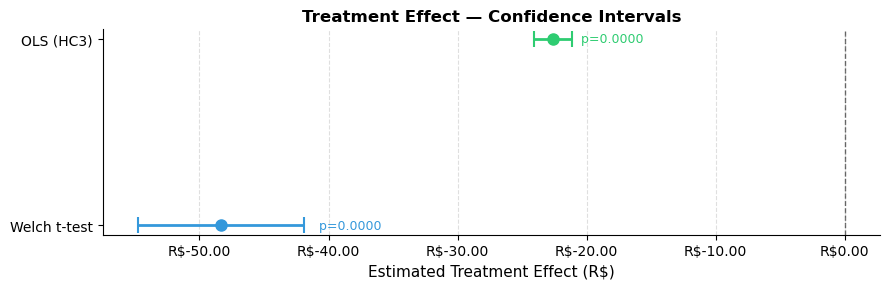

In [15]:
# Confidence interval plot — ttest vs regression estimates side by side
ci_results = [ttest_revenue, reg_revenue]
plot_confidence_intervals(ci_results, path=FIG_DIR / '04_confidence_intervals_revenue.png')

In [16]:
# Summary comparison table across all outcomes and methods
comparison_rows = []
for t, r in [(ttest_revenue, reg_revenue), (ttest_items, reg_items), (ttest_review, reg_review)]:
    comparison_rows.append({
        'outcome':          t['outcome'],
        'ttest_estimate':   round(t['estimate'], 4),
        'ttest_p':          round(t['p_value'], 4),
        'ttest_cohens_d':   round(t['cohens_d'], 4),
        'reg_ate':          round(r['estimate'], 4),
        'reg_p':            round(r['p_value'], 4),
        'reg_r2':           round(r['r_squared'], 4),
        'mw_rank_biserial': round([mw_revenue, mw_items, mw_review]
                                  [['revenue','item_count','review_score']
                                   .index(t['outcome'])]['rank_biserial_r'], 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(TBL_DIR / '04_ab_summary.csv', index=False)
print(f'Saved → {TBL_DIR / "04_ab_summary.csv"}')
comparison_df

Saved → ../outputs/tables/04_ab_summary.csv


,outcome,ttest_estimate,ttest_p,ttest_cohens_d,reg_ate,reg_p,reg_r2,mw_rank_biserial
0,revenue,-48.3236,0.0000,-0.3013,-22.5943,0.0000,0.9083,0.0271
1,item_count,-0.0113,0.6331,-0.0231,0.0000,0.3059,1.0000,-0.0063
2,review_score,0.2329,0.0002,0.1940,0.2734,0.0000,0.1287,-0.0941


## 6. Historical CLV with Tier Distribution

Historical CLV sums each customer's actual revenue over the most recent
12 months and divides the population into four tiers — Bronze, Silver, Gold,
and Platinum — using quartile boundaries. This gives us a backward-looking
baseline: we know exactly how much these customers spent. The limitation is
that it tells us nothing about future behaviour, which is what the
probabilistic model in the next section addresses.

In [17]:
hist_clv = compute_historical_clv(df)
print(f'Customers with historical CLV: {len(hist_clv):,}')
print(f'Columns: {hist_clv.columns.tolist()}')
hist_clv.head()

Customers with historical CLV: 72,620
Columns: ['customer_unique_id', 'historical_clv', 'order_count', 'avg_order_value', 'first_purchase', 'last_purchase', 'tier']


,customer_unique_id,historical_clv,order_count,avg_order_value,first_purchase,last_purchase,tier
0,0000366f3b9a7992bf8c76cfdf3221e2,141.9000,1,141.9000,2018-05-10 10:56:27,2018-05-10 10:56:27,Gold
1,0000b849f77a49e4a4ce2b2a4ca5be3f,27.1900,1,27.1900,2018-05-07 11:11:27,2018-05-07 11:11:27,Bronze
2,0000f6ccb0745a6a4b88665a16c9f078,43.6200,1,43.6200,2017-10-12 20:29:41,2017-10-12 20:29:41,Bronze
3,0004aac84e0df4da2b147fca70cf8255,196.8900,1,196.8900,2017-11-14 19:45:42,2017-11-14 19:45:42,Platinum
4,0004bd2a26a76fe21f786e4fbd80607f,166.9800,1,166.9800,2018-04-05 19:33:16,2018-04-05 19:33:16,Gold


In [18]:
tier_stats = (
    hist_clv.groupby('tier', observed=True)
    .agg(
        customer_count   = ('customer_unique_id', 'count'),
        total_revenue    = ('historical_clv', 'sum'),
        avg_clv          = ('historical_clv', 'mean'),
        median_clv       = ('historical_clv', 'median'),
        avg_order_count  = ('order_count', 'mean'),
    )
    .reset_index()
)
tier_stats['pct_customers'] = (tier_stats['customer_count'] / len(hist_clv) * 100).round(1)
tier_stats['pct_revenue']   = (tier_stats['total_revenue'] / hist_clv['historical_clv'].sum() * 100).round(1)

tier_stats.to_csv(TBL_DIR / '04_historical_clv_tiers.csv', index=False)
print(f'Saved → {TBL_DIR / "04_historical_clv_tiers.csv"}')
tier_stats

Saved → ../outputs/tables/04_historical_clv_tiers.csv


,tier,customer_count,total_revenue,avg_clv,median_clv,avg_order_count,pct_customers,pct_revenue
0,Bronze,18157,"792,938.7300",43.6712,44.0900,1.0017,25.0000,6.6000
1,Silver,18158,"1,524,337.6200",83.9485,83.3600,1.0102,25.0000,12.7000
2,Gold,18152,"2,569,386.4900",141.5484,139.2200,1.0262,25.0000,21.4000
3,Platinum,18153,"7,092,422.9300",390.7025,275.6900,1.0713,25.0000,59.2000


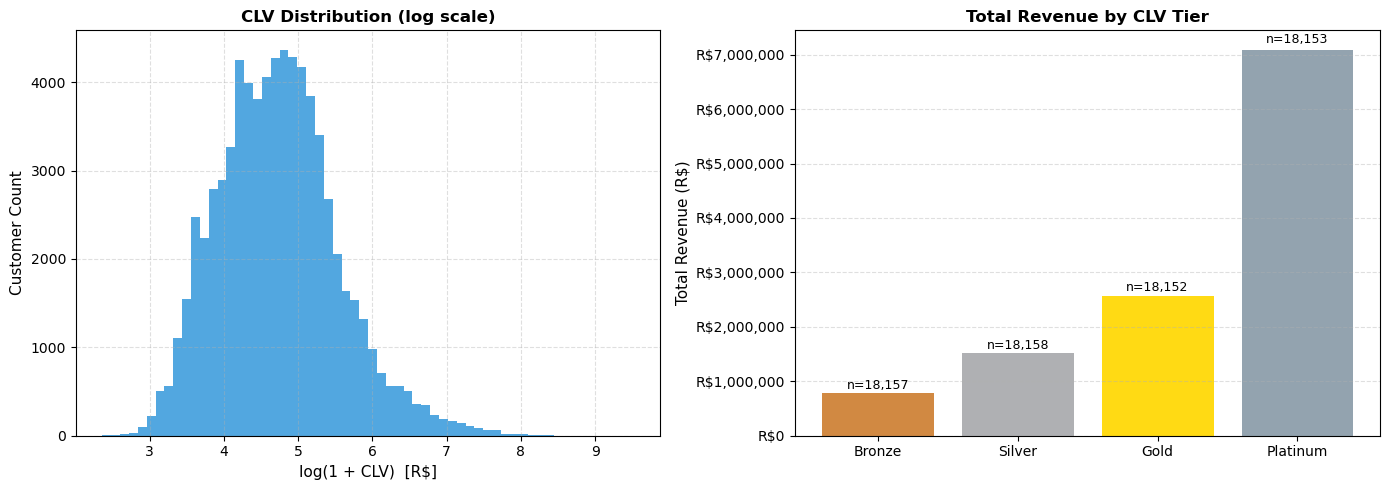

In [19]:
plot_clv_distribution(hist_clv, clv_col='historical_clv',
                      path=FIG_DIR / '04_historical_clv_distribution.png')

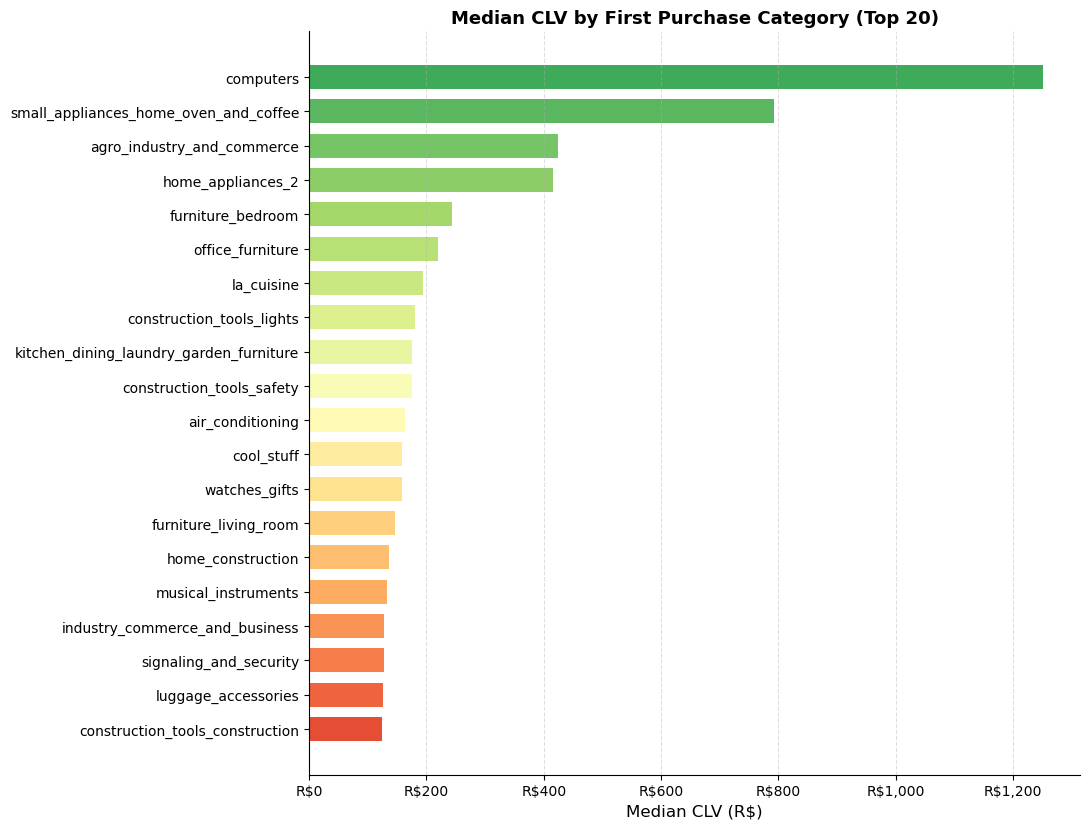

In [20]:
plot_clv_by_category(df, hist_clv, clv_col='historical_clv',
                     path=FIG_DIR / '04_historical_clv_by_category.png')

## 7. Probabilistic CLV Using Lifetimes

The BG/NBD model (Beta-Geometric / Negative Binomial Distribution) treats
every customer as having a latent probability of being 'alive' or 'churned'
and a purchase rate that varies across customers. Combined with a Gamma-Gamma
model for average spend per transaction, it produces a 12-month revenue
forecast for each customer. Unlike the historical sum, this is forward-looking
and accounts for the probability that a customer has already churned without
making another purchase.

In [21]:
prob_clv_df, bgf, ggf = compute_probabilistic_clv(df, months=12)
print(f'Customers scored: {len(prob_clv_df):,}')
print(f'Columns: {prob_clv_df.columns.tolist()}')
prob_clv_df.head()

Customers scored: 93,357
Columns: ['customer_unique_id', 'frequency', 'recency', 'T', 'monetary_value', 'predicted_clv', 'tier']


,customer_unique_id,frequency,recency,T,monetary_value,predicted_clv,tier
0,0000366f3b9a7992bf8c76cfdf3221e2,0.0000,0.0000,16.0000,0.0000,-0.6091,Bronze
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.0000,0.0000,16.0000,0.0000,-0.6091,Bronze
2,0000f46a3911fa3c0805444483337064,0.0000,0.0000,77.0000,0.0000,-0.2557,Platinum
3,0000f6ccb0745a6a4b88665a16c9f078,0.0000,0.0000,46.0000,0.0000,-0.3599,Gold
4,0004aac84e0df4da2b147fca70cf8255,0.0000,0.0000,41.0000,0.0000,-0.3857,Gold


In [22]:
# BG/NBD model parameters
print('BG/NBD parameters:')
print(bgf.summary)
print('\nGamma-Gamma parameters:')
print(ggf.summary)

BG/NBD parameters:
         coef  se(coef)  lower 95% bound  upper 95% bound
r      0.0182    0.0009           0.0164           0.0199
alpha 13.6656    1.0606          11.5869          15.7443
a      0.0806    0.0190           0.0434           0.1179
b      0.0153    0.0038           0.0078           0.0227

Gamma-Gamma parameters:
    coef  se(coef)  lower 95% bound  upper 95% bound
p 4.1294    0.1138           3.9064           4.3523
q 0.4974    0.0134           0.4711           0.5237
v 3.8562    0.1147           3.6313           4.0811


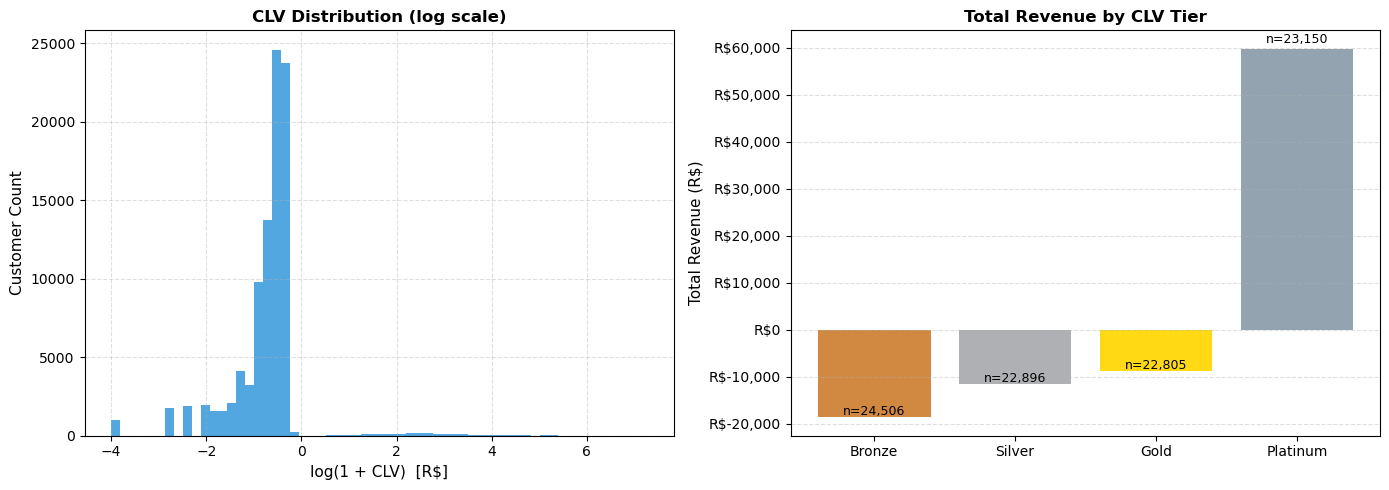

In [23]:
plot_clv_distribution(prob_clv_df, clv_col='predicted_clv',
                      path=FIG_DIR / '04_probabilistic_clv_distribution.png')

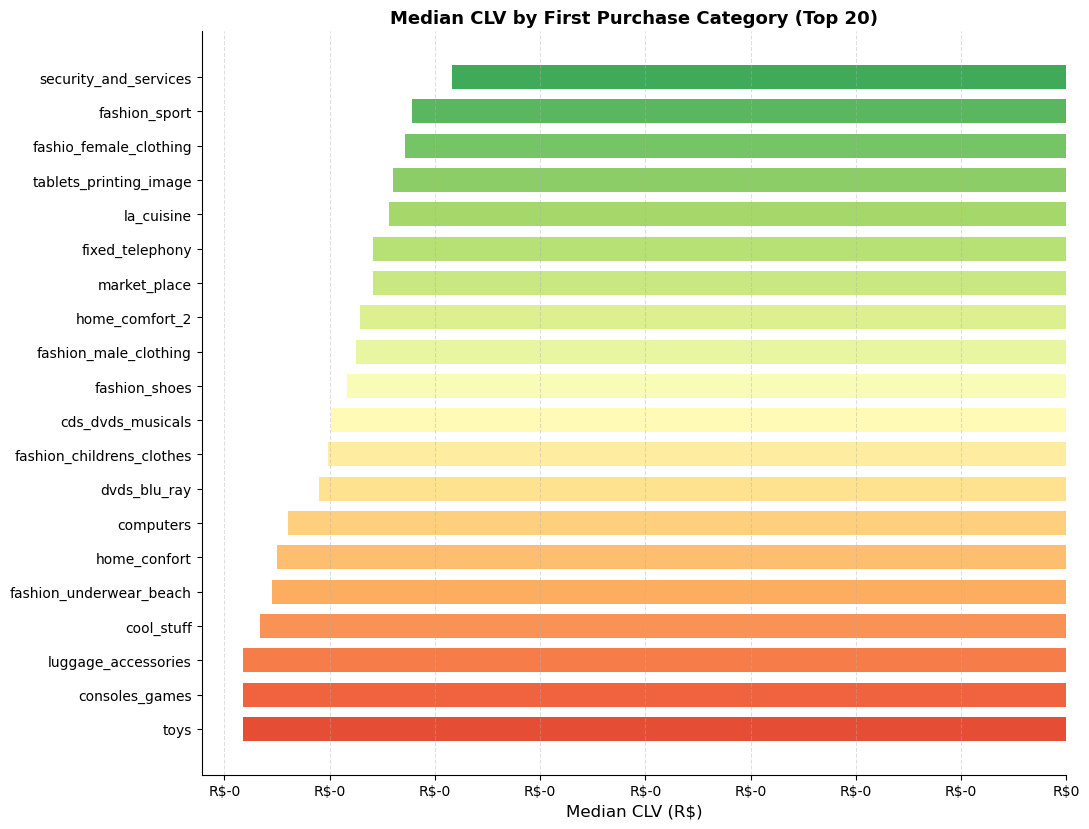

In [24]:
plot_clv_by_category(df, prob_clv_df, clv_col='predicted_clv',
                     path=FIG_DIR / '04_probabilistic_clv_by_category.png')

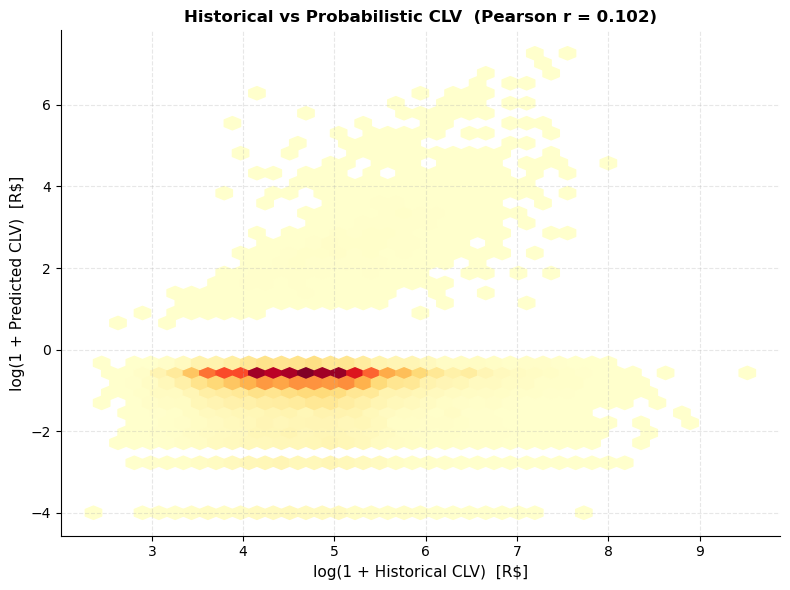

Customers in both models: 72,620
Pearson r (historical vs predicted): 0.1020


In [25]:
# Historical vs Probabilistic CLV — side-by-side scatter per customer
combined = hist_clv[['customer_unique_id', 'historical_clv']].merge(
    prob_clv_df[['customer_unique_id', 'predicted_clv']],
    on='customer_unique_id', how='inner',
)
r_corr = combined[['historical_clv', 'predicted_clv']].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.hexbin(np.log1p(combined['historical_clv']),
          np.log1p(combined['predicted_clv']),
          gridsize=40, cmap='YlOrRd', mincnt=1)
ax.set_xlabel('log(1 + Historical CLV)  [R$]', fontsize=11)
ax.set_ylabel('log(1 + Predicted CLV)  [R$]', fontsize=11)
ax.set_title(f'Historical vs Probabilistic CLV  (Pearson r = {r_corr:.3f})',
             fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_clv_historical_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Customers in both models: {len(combined):,}')
print(f'Pearson r (historical vs predicted): {r_corr:.4f}')

In [26]:
# Save probabilistic CLV scores
prob_clv_df.to_parquet(Path('../data/processed/clv_scores.parquet'), index=False)
print(f'CLV scores saved → data/processed/clv_scores.parquet')

CLV scores saved → data/processed/clv_scores.parquet


## 8. RFM vs CLV Tier Cross-Validation Heatmap

If RFM segmentation and CLV tiers are capturing the same underlying signal,
Champions should map overwhelmingly to Platinum and Lost customers should map
to Bronze. If the alignment is strong it validates both approaches. If it is
weak it reveals that RFM behavioral signals and monetary lifetime value are
picking up different things — for example a high-frequency but low-spend
customer might score as Loyal in RFM but land in Silver CLV. The heatmap
shows row percentages so we can read off each segment's CLV tier distribution.

In [27]:
rfm = compute_rfm(df)
print(f'RFM customers: {len(rfm):,}')

RFM customers: 93,357


In [28]:
# Merge RFM segments with historical CLV tiers
cross_df = rfm[['customer_unique_id', 'segment']].merge(
    hist_clv[['customer_unique_id', 'tier']],
    on='customer_unique_id', how='inner',
)
print(f'Matched customers: {len(cross_df):,}')

tier_order    = ['Bronze', 'Silver', 'Gold', 'Platinum']
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists',
                 'Promising', "Can't Lose Them", 'At Risk', 'Hibernating', 'Lost']

cross_tab = pd.crosstab(
    cross_df['segment'],
    cross_df['tier'],
    normalize='index',
).reindex(
    index=[s for s in segment_order if s in cross_df['segment'].unique()],
    columns=[t for t in tier_order if t in cross_df['tier'].cat.categories],
    fill_value=0,
)

cross_tab.to_csv(TBL_DIR / '04_rfm_clv_crosstab.csv')
print(f'Saved → {TBL_DIR / "04_rfm_clv_crosstab.csv"}')
cross_tab.round(3)

Matched customers: 72,620
Saved → ../outputs/tables/04_rfm_clv_crosstab.csv


tier,Bronze,Silver,Gold,Platinum
segment,,,,
Champions,0.0030,0.0060,0.3650,0.6260
Loyal Customers,0.3080,0.3000,0.2210,0.1710
Potential Loyalists,0.2470,0.2490,0.2600,0.2440
Promising,0.2640,0.2550,0.2560,0.2250
Can't Lose Them,0.2430,0.2610,0.2410,0.2560
At Risk,0.2550,0.2480,0.2520,0.2450
Hibernating,0.2500,0.2680,0.2340,0.2480


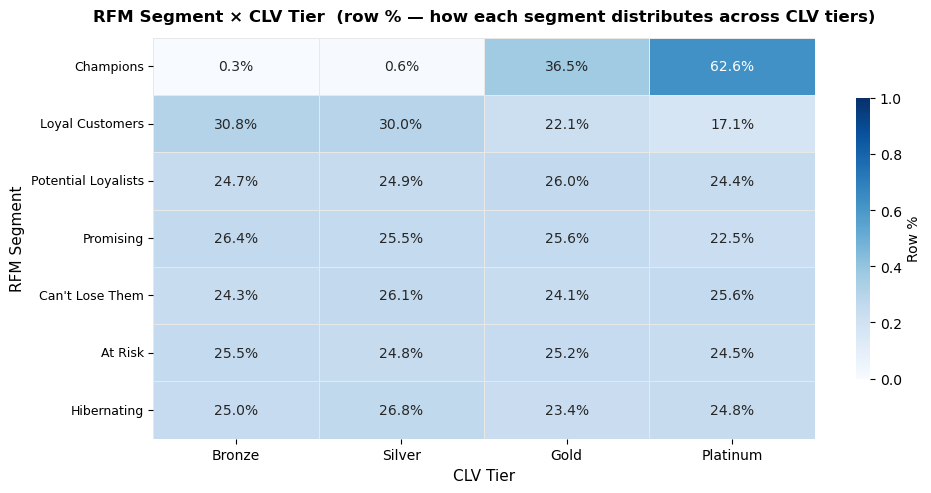

In [29]:
annot_tab = cross_tab.applymap(lambda v: f'{v*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, max(5, len(cross_tab) * 0.72)))
sns.heatmap(
    cross_tab,
    annot=annot_tab,
    fmt='',
    cmap='Blues',
    linewidths=0.4,
    linecolor='#e8e8e8',
    ax=ax,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Row %', 'shrink': 0.7},
    annot_kws={'size': 10},
)
ax.set_title(
    'RFM Segment × CLV Tier  (row % — how each segment distributes across CLV tiers)',
    fontsize=12, fontweight='bold', pad=12,
)
ax.set_xlabel('CLV Tier', fontsize=11)
ax.set_ylabel('RFM Segment', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_rfm_clv_crossvalidation.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Segment-level CLV stats — shows avg predicted CLV per RFM segment
seg_clv = rfm[['customer_unique_id', 'segment', 'monetary', 'frequency', 'recency']].merge(
    prob_clv_df[['customer_unique_id', 'predicted_clv', 'tier']],
    on='customer_unique_id', how='inner',
)

seg_clv_summary = (
    seg_clv.groupby('segment')
    .agg(
        customer_count  = ('customer_unique_id', 'count'),
        avg_predicted_clv = ('predicted_clv', 'mean'),
        median_predicted_clv = ('predicted_clv', 'median'),
        avg_historical_spend = ('monetary', 'mean'),
    )
    .reset_index()
    .sort_values('avg_predicted_clv', ascending=False)
)

seg_clv_summary.to_csv(TBL_DIR / '04_segment_clv_summary.csv', index=False)
print(f'Saved → {TBL_DIR / "04_segment_clv_summary.csv"}')
seg_clv_summary

Saved → ../outputs/tables/04_segment_clv_summary.csv


,segment,customer_count,avg_predicted_clv,median_predicted_clv,avg_historical_spend
2,Champions,6451,6.9502,-0.6091,312.2693
1,Can't Lose Them,14919,0.1745,-0.3179,169.6077
5,Loyal Customers,27206,-0.2117,-0.5331,134.1368
4,Lost,7559,-0.2823,-0.2819,160.3966
0,At Risk,7438,-0.3243,-0.3216,161.5860
3,Hibernating,7427,-0.3653,-0.3648,165.5708
7,Promising,7373,-0.4488,-0.4507,154.0072
6,Potential Loyalists,14984,-0.6869,-0.6567,163.4280


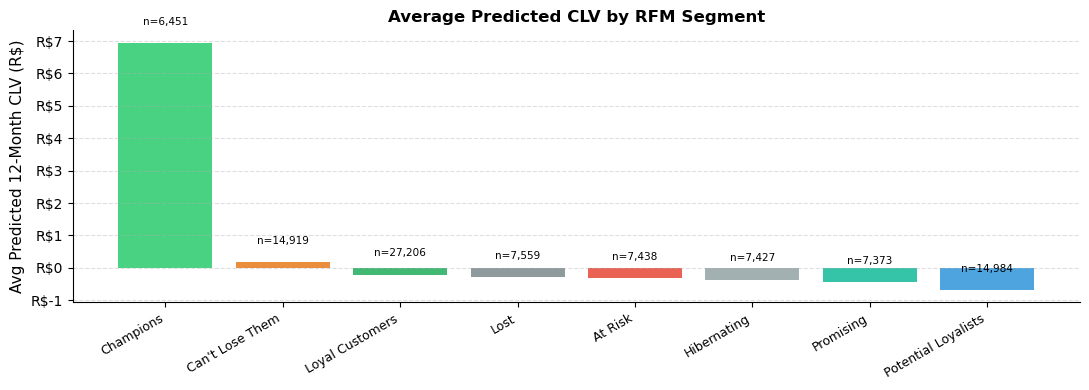

In [31]:
# Bar chart: avg predicted CLV per RFM segment
plot_order = seg_clv_summary['segment'].tolist()
colors     = [SEGMENT_COLORS.get(s, '#bdc3c7') for s in plot_order]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(plot_order, seg_clv_summary['avg_predicted_clv'],
              color=colors, edgecolor='none', alpha=0.88)
for bar, row in zip(bars, seg_clv_summary.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'n={row.customer_count:,}', ha='center', va='bottom', fontsize=7.5)
ax.set_ylabel('Avg Predicted 12-Month CLV (R$)', fontsize=11)
ax.set_xticklabels(plot_order, rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v:,.0f}'))
ax.set_title('Average Predicted CLV by RFM Segment', fontsize=12, fontweight='bold')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_avg_clv_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()